# **0. Setup & Load Data**

In [2]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# **0.1 Load TLT holdings and filter to 44 T-bonds**

In [4]:
holdings_file = "TLT_holdings_10272025.csv"
yield_curve_file = "Yield_Curve.xlsx"

# Skip first 9 lines of metadata
holdings_raw = pd.read_csv(holdings_file, skiprows=9)

# Keep only the 44 Treasury bonds: Fixed Income + non-null CUSIP
bonds = holdings_raw[
    (holdings_raw["Asset Class"] == "Fixed Income") &
    holdings_raw["CUSIP"].notna()
].copy()

print("Total rows in holdings_raw:", holdings_raw.shape[0])
print("Treasury bonds after filtering:", bonds.shape[0])
bonds.head()

Total rows in holdings_raw: 48
Treasury bonds after filtering: 44


,Name,Sector,Asset Class,Market Value,Weight (%),Notional Value,Par Value,CUSIP,ISIN,SEDOL,Price,Location,Exchange,Currency,Duration,YTM (%),FX Rate,Maturity,Coupon (%),Mod. Duration,Yield to Call (%),Yield to Worst (%),Real Duration,Real YTM (%),Market Currency,Accrual Date,Effective Date
0,TREASURY BOND,Treasuries,Fixed Income,"2,777,487,764.02",5.520000,"2,777,487,764.02","4,569,476,100.00",912810SZ2,US912810SZ21,BMWVP21,60.390000,United States,-,USD,17.530000,4.650000,1.000000,"Aug 15, 2051",2.000000,17.780000,-,4.650000,17.780000,4.650000,USD,"Aug 15, 2021","Aug 16, 2021"
1,TREASURY BOND,Treasuries,Fixed Income,"2,423,786,009.98",4.810000,"2,423,786,009.98","4,097,199,200.00",912810TB4,US912810TB44,BMCNFZ0,58.320000,United States,-,USD,17.730000,4.650000,1.000000,"Nov 15, 2051",1.880000,17.980000,-,4.650000,17.980000,4.650000,USD,"Nov 15, 2021","Nov 15, 2021"
2,TREASURY BOND,Treasuries,Fixed Income,"2,325,209,796.05",4.620000,"2,325,209,796.05","2,484,001,200.00",912810TT5,US912810TT51,BRT3QH7,92.790000,United States,-,USD,15.510000,4.590000,1.000000,"Aug 15, 2053",4.130000,15.840000,-,4.590000,15.840000,4.590000,USD,"Aug 15, 2023","Aug 15, 2023"
3,TREASURY BOND,Treasuries,Fixed Income,"2,312,439,192.29",4.590000,"2,312,439,192.29","2,203,532,500.00",912810TV0,US912810TV08,BRBS4M1,102.810000,United States,-,USD,14.950000,4.570000,1.000000,"Nov 15, 2053",4.750000,15.280000,-,4.570000,15.280000,4.570000,USD,"Nov 15, 2023","Nov 15, 2023"
4,TREASURY BOND (OLD),Treasuries,Fixed Income,"2,292,711,907.10",4.550000,"2,292,711,907.10","2,180,837,800.00",912810UK2,US912810UK24,BPJK9V9,103.000000,United States,-,USD,15.330000,4.560000,1.000000,"May 15, 2055",4.750000,15.680000,-,4.560000,15.680000,4.560000,USD,"May 15, 2025","May 15, 2025"


# **0.2 Clean numeric & date columns**

In [6]:
def clean_number(series):
    return (
        series.astype(str)
              .str.replace(',', '', regex=False)
              .str.replace('%', '', regex=False)
              .str.strip()
              .replace({'-': np.nan, '': np.nan})
              .astype(float)
    )

numeric_cols = [
    "Market Value", "Weight (%)", "Notional Value", "Par Value",
    "Price", "Duration", "YTM (%)", "Coupon (%)", "Mod. Duration",
    "Yield to Call (%)", "Yield to Worst (%)", "Real Duration", "Real YTM (%)"
]

for col in numeric_cols:
    if col in bonds.columns:
        bonds[col] = clean_number(bonds[col])

for date_col in ["Maturity", "Accrual Date", "Effective Date"]:
    if date_col in bonds.columns:
        bonds[date_col] = pd.to_datetime(bonds[date_col])

bonds.head()

C:\Users\Deepak\AppData\Local\Temp\ipykernel_9956\4053730836.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'-': np.nan, '': np.nan})


,Name,Sector,Asset Class,Market Value,Weight (%),Notional Value,Par Value,CUSIP,ISIN,SEDOL,Price,Location,Exchange,Currency,Duration,YTM (%),FX Rate,Maturity,Coupon (%),Mod. Duration,Yield to Call (%),Yield to Worst (%),Real Duration,Real YTM (%),Market Currency,Accrual Date,Effective Date
0,TREASURY BOND,Treasuries,Fixed Income,"2,777,487,764.020000",5.520000,"2,777,487,764.020000","4,569,476,100.000000",912810SZ2,US912810SZ21,BMWVP21,60.390000,United States,-,USD,17.530000,4.650000,1.000000,2051-08-15,2.000000,17.780000,NaN,4.650000,17.780000,4.650000,USD,2021-08-15,2021-08-16
1,TREASURY BOND,Treasuries,Fixed Income,"2,423,786,009.980000",4.810000,"2,423,786,009.980000","4,097,199,200.000000",912810TB4,US912810TB44,BMCNFZ0,58.320000,United States,-,USD,17.730000,4.650000,1.000000,2051-11-15,1.880000,17.980000,NaN,4.650000,17.980000,4.650000,USD,2021-11-15,2021-11-15
2,TREASURY BOND,Treasuries,Fixed Income,"2,325,209,796.050000",4.620000,"2,325,209,796.050000","2,484,001,200.000000",912810TT5,US912810TT51,BRT3QH7,92.790000,United States,-,USD,15.510000,4.590000,1.000000,2053-08-15,4.130000,15.840000,NaN,4.590000,15.840000,4.590000,USD,2023-08-15,2023-08-15
3,TREASURY BOND,Treasuries,Fixed Income,"2,312,439,192.290000",4.590000,"2,312,439,192.290000","2,203,532,500.000000",912810TV0,US912810TV08,BRBS4M1,102.810000,United States,-,USD,14.950000,4.570000,1.000000,2053-11-15,4.750000,15.280000,NaN,4.570000,15.280000,4.570000,USD,2023-11-15,2023-11-15
4,TREASURY BOND (OLD),Treasuries,Fixed Income,"2,292,711,907.100000",4.550000,"2,292,711,907.100000","2,180,837,800.000000",912810UK2,US912810UK24,BPJK9V9,103.000000,United States,-,USD,15.330000,4.560000,1.000000,2055-05-15,4.750000,15.680000,NaN,4.560000,15.680000,4.560000,USD,2025-05-15,2025-05-15


# **0.3 Load Yield Curve data**

In [8]:
yc = pd.read_excel(yield_curve_file)
yc["Date"] = pd.to_datetime(yc["Date"])

yc.head()
yc.tail()

,Date,1 Mo,1.5 Mo,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
209,2025-03-11,4.060000,4.040000,4.050000,3.980000,3.880000,3.800000,3.700000,3.600000,3.610000,3.720000,3.900000,4.130000,4.670000,4.690000
210,2025-04-11,4.020000,4.040000,4.010000,3.960000,3.870000,3.780000,3.670000,3.580000,3.590000,3.690000,3.880000,4.100000,4.650000,4.670000
211,2025-05-11,4.000000,4.020000,4.000000,3.960000,3.870000,3.790000,3.710000,3.630000,3.650000,3.760000,3.950000,4.170000,4.720000,4.740000
212,2025-06-11,4.020000,3.960000,3.980000,3.930000,3.840000,3.760000,3.650000,3.570000,3.580000,3.690000,3.870000,4.110000,4.670000,4.690000
213,2025-07-11,4.010000,3.960000,3.980000,3.920000,3.830000,3.760000,3.630000,3.550000,3.570000,3.670000,3.870000,4.110000,4.680000,4.700000


# **1. Curve Interpolation – continuous curve function**
#### We convert the 14 pillar rates into a continuous function y(t) = yield for any maturity t in years, using linear interpolation.

### **1.1 Define pillar tenors and helper to get curve for a given date**

In [11]:
# Pillars in ascending maturity
PILLAR_COLS = ["1 Mo", "1.5 Mo", "2 Mo", "3 Mo", "4 Mo", "6 Mo",
               "1 Yr", "2 Yr", "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr", "30 Yr"]

PILLAR_TENORS = {
    "1 Mo": 1/12,
    "1.5 Mo": 1.5/12,
    "2 Mo": 2/12,
    "3 Mo": 3/12,
    "4 Mo": 4/12,
    "6 Mo": 0.5,
    "1 Yr": 1.0,
    "2 Yr": 2.0,
    "3 Yr": 3.0,
    "5 Yr": 5.0,
    "7 Yr": 7.0,
    "10 Yr": 10.0,
    "20 Yr": 20.0,
    "30 Yr": 30.0,
}

def get_curve_row_for_date(curve_df, target_date):
    """
    Return the row of curve_df whose Date is closest to target_date.
    """
    df = curve_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    idx = (df["Date"] - target_date).abs().idxmin()
    return df.loc[idx]


### **1.2 Build continuous curve function y(t)**

In [13]:
def build_curve_function_from_row(curve_row):
    """
    Returns a function y(t, which='linear' or 'spline') that gives the interpolated yield (in decimal)
    for any maturity t (in years).
    """
    mats = np.array([PILLAR_TENORS[c] for c in PILLAR_COLS], dtype=float)
    rates_percent = np.array([curve_row[c] for c in PILLAR_COLS], dtype=float)
    rates = rates_percent / 100.0  # convert % -> decimal

    # Sort by maturity in case
    order = np.argsort(mats)
    mats = mats[order]
    rates = rates[order]

    # Linear interpolator using np.interp
    def y_linear(t):
        t = np.asarray(t, dtype=float)
        return np.interp(t, mats, rates)

    # Cubic spline interpolator
    spline = CubicSpline(mats, rates)
    def y_spline(t):
        t = np.asarray(t, dtype=float)
        return spline(t)

    def y_func(t, which="spline"):
        """
        which = 'linear' or 'spline'
        default is 'spline' (what we use for pricing and plots)
        """
        if which == "linear":
            return y_linear(t)
        else:
            return y_spline(t)

    return y_func


### **1.3 GRAPH 1: Yield curve visualization**

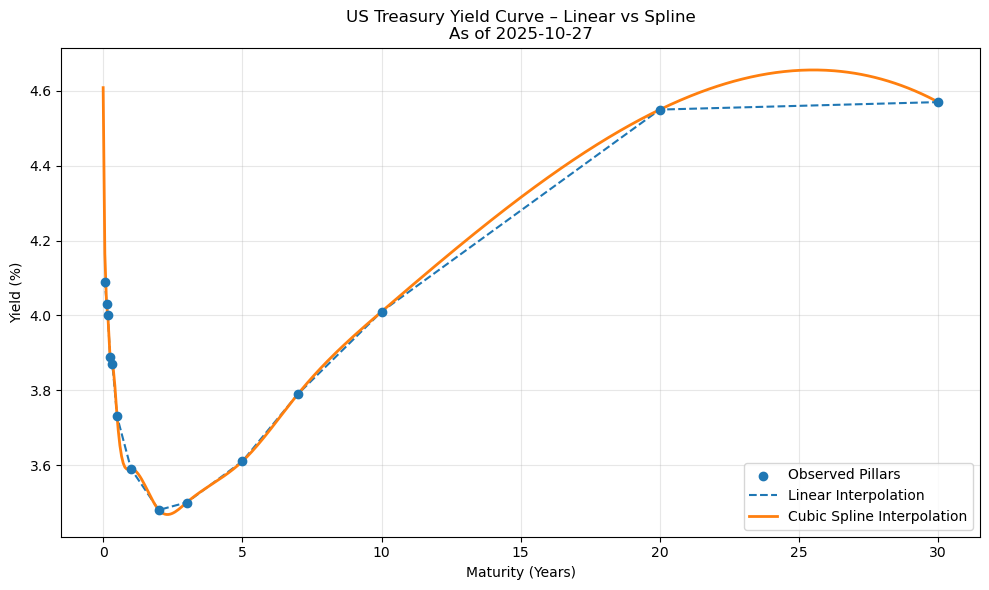

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Use the curve as of 2025-10-27
valuation_date_curve = pd.to_datetime("2025-10-27")
curve_row_1027 = get_curve_row_for_date(yc, valuation_date_curve)
curve_rate = build_curve_function_from_row(curve_row_1027)

# Dense grid of maturities (0 to 30 years)
t_dense = np.linspace(0.0, 30.0, 500)

# Interpolated yields in DECIMAL
y_linear_dec = curve_rate(t_dense, which="linear")
y_spline_dec = curve_rate(t_dense, which="spline")

# Convert to PERCENT for plotting
y_linear = 100.0 * y_linear_dec
y_spline = 100.0 * y_spline_dec

# Pillar tenors and observed yields
pillar_tenors = np.array([PILLAR_TENORS[c] for c in PILLAR_COLS])
pillar_yields = np.array([curve_row_1027[c] for c in PILLAR_COLS], dtype=float)

plt.figure(figsize=(10, 6))

# Observed data points
plt.scatter(
    pillar_tenors,
    pillar_yields,
    label="Observed Pillars",
    zorder=3
)

# Interpolated curves
plt.plot(
    t_dense,
    y_linear,
    linestyle="--",
    linewidth=1.5,
    label="Linear Interpolation"
)
plt.plot(
    t_dense,
    y_spline,
    linewidth=2.0,
    label="Cubic Spline Interpolation"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("US Treasury Yield Curve – Linear vs Spline\nAs of 2025-10-27")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### **Base vs bumped curve (bump in last pillar, e.g., 30y)**

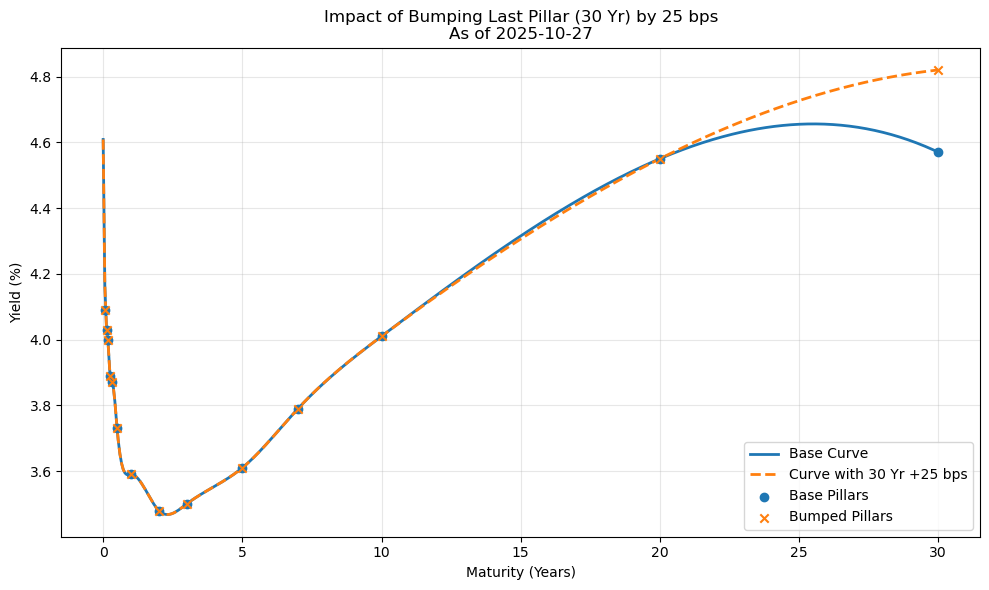

In [17]:
# Graph: effect of bumping the LAST pillar (e.g., 30Y) by 25 bps

bump_bp = 25.0  # bump size in basis points
last_col = PILLAR_COLS[-1]

base_row = curve_row_1027
bumped_row = base_row.copy()
bumped_row[last_col] = bumped_row[last_col] + bump_bp / 100.0  # bp -> %

base_curve_func = build_curve_function_from_row(base_row)
bumped_curve_func = build_curve_function_from_row(bumped_row)

# Use the same dense grid
t_dense = np.linspace(0.0, 30.0, 500)

y_base = 100.0 * base_curve_func(t_dense)      # decimal -> %
y_bumped = 100.0 * bumped_curve_func(t_dense)  # decimal -> %

plt.figure(figsize=(10, 6))

plt.plot(
    t_dense,
    y_base,
    linewidth=2.0,
    label="Base Curve"
)
plt.plot(
    t_dense,
    y_bumped,
    linestyle="--",
    linewidth=2.0,
    label=f"Curve with {last_col} +{bump_bp:.0f} bps"
)

# Mark the pillars
pillar_tenors = np.array([PILLAR_TENORS[c] for c in PILLAR_COLS])
pillar_yields_base = np.array([base_row[c] for c in PILLAR_COLS], dtype=float)
pillar_yields_bumped = np.array([bumped_row[c] for c in PILLAR_COLS], dtype=float)

plt.scatter(
    pillar_tenors,
    pillar_yields_base,
    label="Base Pillars",
    zorder=3
)
plt.scatter(
    pillar_tenors,
    pillar_yields_bumped,
    marker="x",
    label="Bumped Pillars",
    zorder=4
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title(f"Impact of Bumping Last Pillar ({last_col}) by {bump_bp:.0f} bps\nAs of 2025-10-27")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### **1.4 Discount factor function**
#### We will use continuously compounded yields: $DF(t) = e^{-y(t)\, t}$


In [19]:
def discount_factor(t, y_func):
    """
    t: time in years (scalar or array)
    y_func: continuous yield curve function
    """
    t = np.asarray(t, dtype=float)
    y = y_func(t)
    return np.exp(-y * t)


# **2. Bond Pricing Function (PV of each bond)**

#### Assumptions from instructions:

#### 1) Coupons are semiannual

#### 2) We ignore weekend/holiday calendar noise

#### 3) Coupon cash flow = coupon_rate * notional / 2

#### 4) Add notional at final row

### **2.1 Coupon schedule and cash flows**

In [22]:
from pandas.tseries.offsets import DateOffset

valuation_date = pd.to_datetime("2025-10-27")  # as per instructions

def generate_cashflows_for_bond(bond_row, val_date):
    """
    Generate future cashflow dates and amounts for a semiannual coupon bond.
    - bond_row: row from bonds DataFrame
    - val_date: valuation date (pd.Timestamp)
    Returns:
        times (years from val_date),
        cashflows (same length)
    """
    maturity = pd.to_datetime(bond_row["Maturity"])
    coupon_rate = bond_row["Coupon (%)"] / 100.0  # annual coupon in decimal
    notional = bond_row["Par Value"]

    # Generate coupon dates backwards from maturity in 6-month steps
    dates = []
    d = maturity
    while d > val_date:
        dates.append(d)
        d = d - DateOffset(months=6)

    dates = sorted(dates)
    if len(dates) == 0:
        return np.array([]), np.array([])

    # Semiannual coupon
    cpn = notional * coupon_rate / 2.0
    cfs = np.array([cpn] * len(dates), dtype=float)
    cfs[-1] += notional  # add principal at maturity

    times = np.array([(d - val_date).days / 365.0 for d in dates], dtype=float)
    return times, cfs


### **2.2 Bond pricing using the curve**

In [24]:
def price_bond_from_curve(bond_row, val_date, y_func):
    """
    Clean price = sum of discounted cashflows (no accrued included).
    """
    times, cfs = generate_cashflows_for_bond(bond_row, val_date)
    if len(times) == 0:
        return 0.0
    dfs = discount_factor(times, y_func)
    return float(np.sum(cfs * dfs))


### **2.3 Portfolio PV**

In [26]:
def portfolio_pv(bonds_df, val_date, y_func):
    total = 0.0
    for _, row in bonds_df.iterrows():
        total += price_bond_from_curve(row, val_date, y_func)
    return total


### **2.4 Example: PV as of 2025-10-27**

In [28]:
curve_row_1027 = get_curve_row_for_date(yc, valuation_date)
y_curve_1027 = build_curve_function_from_row(curve_row_1027)

pv_portfolio_1027 = portfolio_pv(bonds, valuation_date, y_curve_1027)
print("Portfolio PV as of 2025-10-27 (model):", pv_portfolio_1027)


Portfolio PV as of 2025-10-27 (model): 50760121681.48317


# **3. Portfolio Delta Ladder (14 pillar shocks)**

**Definition:** For each of the 14 curve points, bump that point by e.g. +1 bp (0.0001 in decimal), rebuild the curve, reprice the portfolio, compute:

$$
\Delta_i = \frac{PV_{\text{bumped}, i} - PV_{\text{base}}}{\Delta y_i}
$$


### **3.1 Delta ladder function**

In [31]:
def compute_portfolio_delta_ladder(bonds_df, val_date, curve_df, bump_bp=1.0):
    """
    Compute delta ladder w.r.t. the 14 yield pillars.
    bump_bp: shock size in basis points (e.g. 1 = 1bp)
    Returns:
        deltas: np.array shape (14,)
        pv_base: float
    """
    bump_size = bump_bp / 10000.0  # 1 bp -> 0.0001

    base_row = get_curve_row_for_date(curve_df, val_date)
    base_curve_func = build_curve_function_from_row(base_row)

    pv_base = portfolio_pv(bonds_df, val_date, base_curve_func)

    deltas = []
    for col in PILLAR_COLS:
        bumped_row = base_row.copy()
        bumped_row[col] = bumped_row[col] + bump_bp / 100.0  # yields stored in %
        bumped_curve_func = build_curve_function_from_row(bumped_row)

        pv_bumped = portfolio_pv(bonds_df, val_date, bumped_curve_func)
        delta_i = (pv_bumped - pv_base) / bump_size
        deltas.append(delta_i)

    deltas = np.array(deltas, dtype=float)
    return deltas, pv_base

### **3.2 Run and inspect delta ladder**

In [33]:
portfolio_delta_ladder, pv_base = compute_portfolio_delta_ladder(
    bonds, valuation_date, yc, bump_bp=1.0
)

delta_df = pd.DataFrame({
    "Pillar": PILLAR_COLS,
    "Maturity (yrs)": [PILLAR_TENORS[c] for c in PILLAR_COLS],
    "Delta": portfolio_delta_ladder
})

delta_df


,Pillar,Maturity (yrs),Delta
0,1 Mo,0.083333,"-158,446,652.908325"
1,1.5 Mo,0.125000,"769,768,315.353394"
2,2 Mo,0.166667,"-1,650,936,386.718750"
3,3 Mo,0.250000,"4,531,643,595.886230"
4,4 Mo,0.333333,"-9,096,178,883.895874"
5,6 Mo,0.500000,"9,970,508,594.131470"
6,1 Yr,1.000000,"-12,683,432,654.495239"
7,2 Yr,2.000000,"24,111,797,469.863892"
8,3 Yr,3.000000,"-60,195,589,867.019653"
9,5 Yr,5.000000,"119,443,336,024.703979"


# **4. Curve PCA (9/1/2025 – 10/27/2025)**

#### We use daily changes in yields for the 14 pillars.

### **4.1 Build curve matrix for PCA**

In [36]:
def get_curve_matrix_for_pca(curve_df, start_date, end_date):
    df = curve_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    mask = (df["Date"] >= start_date) & (df["Date"] <= end_date)
    sub = df.loc[mask, ["Date"] + PILLAR_COLS].dropna()

    dates = sub["Date"].values
    Y = sub[PILLAR_COLS].values / 100.0  # convert % -> decimal
    return dates, Y

start_pca = pd.to_datetime("2025-09-01")
end_pca = valuation_date

dates_pca, Y = get_curve_matrix_for_pca(yc, start_pca, end_pca)
print("Number of curve observations:", len(dates_pca))


Number of curve observations: 34


### **4.2 Perform PCA on daily yield changes**

In [38]:
# Daily changes in yields
dY = np.diff(Y, axis=0)      # shape: (T-1, 14)
dY_centered = dY - dY.mean(axis=0, keepdims=True)

# Covariance matrix of changes
cov = np.cov(dY_centered, rowvar=False)  # (14 x 14)

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(cov)  # eigenvalues in ascending order
order = np.argsort(eigvals)[::-1]       # sort descending

eigvals = eigvals[order]
eigvecs = eigvecs[:, order]            # columns = PCs

# PC scores (time series)
scores = dY_centered @ eigvecs         # shape: (T-1, 14)

print("Eigenvalues:", eigvals[:5])


Eigenvalues: [4.82509635e-06 7.47433503e-07 3.57751864e-07 6.87603006e-08
 5.97370790e-08]


#### **We will use PC1 and PC2:**

In [40]:
PC1 = eigvecs[:, 0]  # loadings across 14 pillars
PC2 = eigvecs[:, 1]

pc_df = pd.DataFrame({
    "Pillar": PILLAR_COLS,
    "Maturity (yrs)": [PILLAR_TENORS[c] for c in PILLAR_COLS],
    "PC1 loading": PC1,
    "PC2 loading": PC2,
})
pc_df


,Pillar,Maturity (yrs),PC1 loading,PC2 loading
0,1 Mo,0.083333,0.057508,0.227817
1,1.5 Mo,0.125000,0.080463,0.223192
2,2 Mo,0.166667,0.176542,0.213286
3,3 Mo,0.250000,0.250982,0.173168
4,4 Mo,0.333333,0.268672,0.350430
5,6 Mo,0.500000,0.338272,0.433846
6,1 Yr,1.000000,0.333849,0.187848
7,2 Yr,2.000000,0.320354,-0.048506
8,3 Yr,3.000000,0.331883,-0.067677
9,5 Yr,5.000000,0.320274,-0.168091


### **PCA loadings graph (PC1 & PC2 vs maturity)**

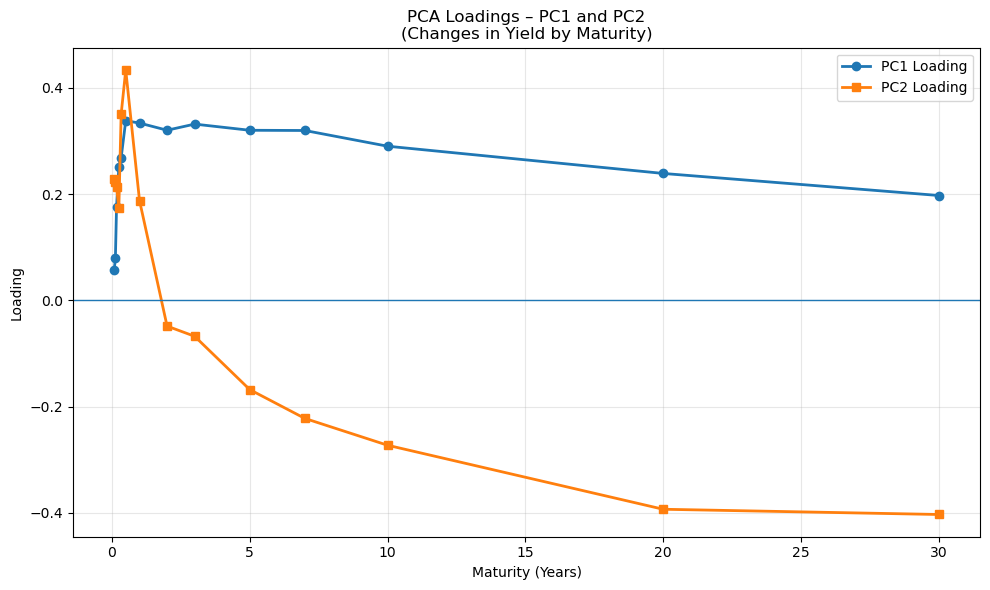

In [42]:
# Graph: PCA loadings for PC1 and PC2
pillar_tenors = np.array([PILLAR_TENORS[c] for c in PILLAR_COLS])

plt.figure(figsize=(10, 6))

plt.plot(
    pillar_tenors,
    PC1,
    marker="o",
    linewidth=2.0,
    label="PC1 Loading"
)
plt.plot(
    pillar_tenors,
    PC2,
    marker="s",
    linewidth=2.0,
    label="PC2 Loading"
)

plt.axhline(0.0, linewidth=1.0)

plt.xlabel("Maturity (Years)")
plt.ylabel("Loading")
plt.title("PCA Loadings – PC1 and PC2\n(Changes in Yield by Maturity)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# **5. Delta Ladder of a 10y ZCB (closed form)**

We now compute the **delta ladder of a 10y zero-coupon bond** using the interpolation model directly, **no scenario curves**.

For a ZCB of maturity $T$:

- Find the two curve pillars bracketing $T$, say $t_0, t_1$ with yields $y_0, y_1$.
- Interpolated yield:  
  $y(T) = (1 - \alpha)\,y_0 + \alpha\,y_1$, where $\alpha = \dfrac{T - t_0}{t_1 - t_0}$.
- Price (continuous compounding):  
  $P = N e^{-y(T)T}$.
- Sensitivity to each pillar:  
  - $\dfrac{\partial P}{\partial y_0} = -TP(1 - \alpha)$  
  - $\dfrac{\partial P}{\partial y_1} = -TP\alpha$
- All other pillars have zero delta.


### **5.1 ZCB price and delta ladder**

In [45]:
def zcb_price_and_delta_ladder(T, notional, curve_row):
    """
    T: maturity in years
    notional: principal of the ZCB (we usually use 1.0)
    curve_row: row from yield curve DataFrame for valuation date
    Returns:
        price: ZCB price
        delta_ladder: np.array of length 14 (same order as PILLAR_COLS)
    """
    mats = np.array([PILLAR_TENORS[c] for c in PILLAR_COLS], dtype=float)
    rates = np.array([curve_row[c] for c in PILLAR_COLS], dtype=float) / 100.0

    # Ensure ascending order
    order = np.argsort(mats)
    mats = mats[order]
    rates = rates[order]

    # locate interval containing T
    if T <= mats[0]:
        k0, k1 = 0, 1
    elif T >= mats[-1]:
        k0, k1 = len(mats)-2, len(mats)-1
    else:
        k1 = np.searchsorted(mats, T)
        k0 = k1 - 1

    t0, t1 = mats[k0], mats[k1]
    y0, y1 = rates[k0], rates[k1]

    alpha = (T - t0) / (t1 - t0)
    yT = (1 - alpha) * y0 + alpha * y1

    # continuous comp
    P = notional * np.exp(-yT * T)
    dP_dyT = -T * P

    delta = np.zeros_like(rates)
    delta[k0] = dP_dyT * (1 - alpha)
    delta[k1] = dP_dyT * alpha

    # Reorder back to original PILLAR_COLS order
    # But since PILLAR_COLS were already in ascending maturity, order is identity.
    # So we can directly return delta under that assumption.
    return P, delta


### **5.2 10y ZCB delta ladder as of 2025-10-27**

In [47]:
T_10y = 10.0
notional_10y = 1.0  # unit notional; hedge notional will scale this

zcb10_price, zcb10_delta_ladder = zcb_price_and_delta_ladder(
    T_10y, notional_10y, curve_row_1027
)

zcb10_df = pd.DataFrame({
    "Pillar": PILLAR_COLS,
    "Maturity (yrs)": [PILLAR_TENORS[c] for c in PILLAR_COLS],
    "Delta (10y ZCB, notional=1)": zcb10_delta_ladder
})
zcb10_df


,Pillar,Maturity (yrs),"Delta (10y ZCB, notional=1)"
0,1 Mo,0.083333,0.000000
1,1.5 Mo,0.125000,0.000000
2,2 Mo,0.166667,0.000000
3,3 Mo,0.250000,0.000000
4,4 Mo,0.333333,0.000000
5,6 Mo,0.500000,0.000000
6,1 Yr,1.000000,0.000000
7,2 Yr,2.000000,0.000000
8,3 Yr,3.000000,0.000000
9,5 Yr,5.000000,0.000000


# **6. Hedge out PC1 with 10y ZCB**

### **6.1 PC1 exposures of portfolio and 10y ZCB**

In [50]:
# Portfolio exposure to PC1
portfolio_PC1_exposure = portfolio_delta_ladder @ PC1

# 10y ZCB exposure to PC1 (per unit notional)
zcb10_PC1_exposure = zcb10_delta_ladder @ PC1

print("Portfolio PC1 exposure:", portfolio_PC1_exposure)
print("10y ZCB PC1 exposure per unit notional:", zcb10_PC1_exposure)


Portfolio PC1 exposure: -196714114302.94305
10y ZCB PC1 exposure per unit notional: -1.9437378535703917


## **6.2 Required notional of 10y ZCB to hedge PC1**

We want: &nbsp;&nbsp;&nbsp;&nbsp;$\text{Portfolio PC1} + N_{10} \cdot \text{ZCB10 PC1} = 0$


In [52]:
N_10_PC1 = - portfolio_PC1_exposure / zcb10_PC1_exposure
print("Hedge notional for 10y ZCB (PC1 hedge):", N_10_PC1)


Hedge notional for 10y ZCB (PC1 hedge): -101204035277.4964


### **6.3 New delta ladder after adding 10y ZCB hedge**

In [54]:
delta_ladder_after_PC1 = portfolio_delta_ladder + N_10_PC1 * zcb10_delta_ladder

delta_pc1_df = pd.DataFrame({
    "Pillar": PILLAR_COLS,
    "Maturity (yrs)": [PILLAR_TENORS[c] for c in PILLAR_COLS],
    "Delta Before Hedge": portfolio_delta_ladder,
    "Delta After PC1 Hedge": delta_ladder_after_PC1
})
delta_pc1_df


,Pillar,Maturity (yrs),Delta Before Hedge,Delta After PC1 Hedge
0,1 Mo,0.083333,"-158,446,652.908325","-158,446,652.908325"
1,1.5 Mo,0.125000,"769,768,315.353394","769,768,315.353394"
2,2 Mo,0.166667,"-1,650,936,386.718750","-1,650,936,386.718750"
3,3 Mo,0.250000,"4,531,643,595.886230","4,531,643,595.886230"
4,4 Mo,0.333333,"-9,096,178,883.895874","-9,096,178,883.895874"
5,6 Mo,0.500000,"9,970,508,594.131470","9,970,508,594.131470"
6,1 Yr,1.000000,"-12,683,432,654.495239","-12,683,432,654.495239"
7,2 Yr,2.000000,"24,111,797,469.863892","24,111,797,469.863892"
8,3 Yr,3.000000,"-60,195,589,867.019653","-60,195,589,867.019653"
9,5 Yr,5.000000,"119,443,336,024.703979","119,443,336,024.703979"


# **7. PnL on 10/28/2025 with and without PC1 hedge**

We approximate PnL from 10/27 to 10/28 using first-order delta:

&nbsp;&nbsp;&nbsp;&nbsp;$\text{PnL} \approx \sum_i \Delta_i\, \Delta y_i$

where $\Delta y_i$ are the changes in pillar yields (in decimal).


### **7.1 Get curve on 10/28/2025 and compute yield changes**

In [57]:
date_1028 = pd.to_datetime("2025-10-28")

curve_row_1028 = get_curve_row_for_date(yc, date_1028)

y_1027 = np.array([curve_row_1027[c] for c in PILLAR_COLS], dtype=float) / 100.0
y_1028 = np.array([curve_row_1028[c] for c in PILLAR_COLS], dtype=float) / 100.0

delta_y = y_1028 - y_1027
delta_y_df = pd.DataFrame({
    "Pillar": PILLAR_COLS,
    "Maturity (yrs)": [PILLAR_TENORS[c] for c in PILLAR_COLS],
    "Yield 10/27": y_1027,
    "Yield 10/28": y_1028,
    "Change (decimal)": delta_y
})
delta_y_df


,Pillar,Maturity (yrs),Yield 10/27,Yield 10/28,Change (decimal)
0,1 Mo,0.083333,0.040900,0.040700,-0.000200
1,1.5 Mo,0.125000,0.040300,0.040200,-0.000100
2,2 Mo,0.166667,0.040000,0.039700,-0.000300
3,3 Mo,0.250000,0.038900,0.038900,0.000000
4,4 Mo,0.333333,0.038700,0.038600,-0.000100
5,6 Mo,0.500000,0.037300,0.037200,-0.000100
6,1 Yr,1.000000,0.035900,0.035900,0.000000
7,2 Yr,2.000000,0.034800,0.034700,-0.000100
8,3 Yr,3.000000,0.035000,0.035000,0.000000
9,5 Yr,5.000000,0.036100,0.036000,-0.000100


### **7.2 PnL without hedge vs with PC1 hedge**

In [59]:
pnl_without_hedge_PC1 = portfolio_delta_ladder @ delta_y
pnl_with_PC1_hedge = delta_ladder_after_PC1 @ delta_y

print("Approx PnL (portfolio only):", pnl_without_hedge_PC1)
print("Approx PnL (with 10y PC1 hedge):", pnl_with_PC1_hedge)


Approx PnL (portfolio only): 166066034.20428255
Approx PnL (with 10y PC1 hedge): 30523457.402566567


# **8. Hedge out both PC1 and PC2 (10y & 2y ZCB)**

Now we **forget the PC1-only hedge**, go back to the original portfolio delta ladder, and hedge **both PC1 and PC2** using:

- 10y ZCB  
- 2y ZCB


### **8.1 Delta ladder of 2y ZCB**

In [62]:
T_2y = 2.0
notional_2y = 1.0

zcb2_price, zcb2_delta_ladder = zcb_price_and_delta_ladder(
    T_2y, notional_2y, curve_row_1027
)

zcb2_df = pd.DataFrame({
    "Pillar": PILLAR_COLS,
    "Maturity (yrs)": [PILLAR_TENORS[c] for c in PILLAR_COLS],
    "Delta (2y ZCB, notional=1)": zcb2_delta_ladder
})
zcb2_df


,Pillar,Maturity (yrs),"Delta (2y ZCB, notional=1)"
0,1 Mo,0.083333,0.000000
1,1.5 Mo,0.125000,0.000000
2,2 Mo,0.166667,0.000000
3,3 Mo,0.250000,0.000000
4,4 Mo,0.333333,0.000000
5,6 Mo,0.500000,0.000000
6,1 Yr,1.000000,-0.000000
7,2 Yr,2.000000,-1.865534
8,3 Yr,3.000000,0.000000
9,5 Yr,5.000000,0.000000


### **8.2 PC1 and PC2 exposures**

In [64]:
# Portfolio exposures
port_PC1 = portfolio_delta_ladder @ PC1
port_PC2 = portfolio_delta_ladder @ PC2

# 10y ZCB per unit notional
z10_PC1 = zcb10_delta_ladder @ PC1
z10_PC2 = zcb10_delta_ladder @ PC2

# 2y ZCB per unit notional
z2_PC1 = zcb2_delta_ladder @ PC1
z2_PC2 = zcb2_delta_ladder @ PC2

print("Portfolio PC1, PC2:", port_PC1, port_PC2)
print("10y ZCB PC1, PC2 per unit:", z10_PC1, z10_PC2)
print("2y ZCB PC1, PC2 per unit:", z2_PC1, z2_PC2)


Portfolio PC1, PC2: -196714114302.94305 311258589057.7278
10y ZCB PC1, PC2 per unit: -1.9437378535703917 1.8272003904728487
2y ZCB PC1, PC2 per unit: -0.5976303234882383 0.09048896188737544


### **8.3 Solve for hedge notionals N10, N2**

We want:

&nbsp;&nbsp;&nbsp;&nbsp;$\left\{
\begin{array}{l}
\text{port\_PC1} + N_{10}\, z10\_PC1 + N_{2}\, z2\_PC1 = 0 \\
\text{port\_PC2} + N_{10}\, z10\_PC2 + N_{2}\, z2\_PC2 = 0
\end{array}
\right.$


In [66]:
A = np.array([
    [z10_PC1, z2_PC1],
    [z10_PC2, z2_PC2]
], dtype=float)

b = -np.array([port_PC1, port_PC2], dtype=float)

N_10_PC1_PC2, N_2_PC1_PC2 = np.linalg.solve(A, b)

print("Hedge notional for 10y ZCB (PC1+PC2):", N_10_PC1_PC2)
print("Hedge notional for 2y ZCB  (PC1+PC2):", N_2_PC1_PC2)


Hedge notional for 10y ZCB (PC1+PC2): -183622383225.6429
Hedge notional for 2y ZCB  (PC1+PC2): 268058122955.50436


### **8.4 New delta ladder after PC1+PC2 hedge**

In [68]:
delta_ladder_after_PC1_PC2 = (
    portfolio_delta_ladder
    + N_10_PC1_PC2 * zcb10_delta_ladder
    + N_2_PC1_PC2 * zcb2_delta_ladder
)

delta_pc12_df = pd.DataFrame({
    "Pillar": PILLAR_COLS,
    "Maturity (yrs)": [PILLAR_TENORS[c] for c in PILLAR_COLS],
    "Delta Before Hedge": portfolio_delta_ladder,
    "Delta After PC1+PC2 Hedge": delta_ladder_after_PC1_PC2
})
delta_pc12_df


,Pillar,Maturity (yrs),Delta Before Hedge,Delta After PC1+PC2 Hedge
0,1 Mo,0.083333,"-158,446,652.908325","-158,446,652.908325"
1,1.5 Mo,0.125000,"769,768,315.353394","769,768,315.353394"
2,2 Mo,0.166667,"-1,650,936,386.718750","-1,650,936,386.718750"
3,3 Mo,0.250000,"4,531,643,595.886230","4,531,643,595.886230"
4,4 Mo,0.333333,"-9,096,178,883.895874","-9,096,178,883.895874"
5,6 Mo,0.500000,"9,970,508,594.131470","9,970,508,594.131470"
6,1 Yr,1.000000,"-12,683,432,654.495239","-12,683,432,654.495239"
7,2 Yr,2.000000,"24,111,797,469.863892","-475,959,665,553.564087"
8,3 Yr,3.000000,"-60,195,589,867.019653","-60,195,589,867.019653"
9,5 Yr,5.000000,"119,443,336,024.703979","119,443,336,024.703979"


### **Delta ladder before/after hedge**

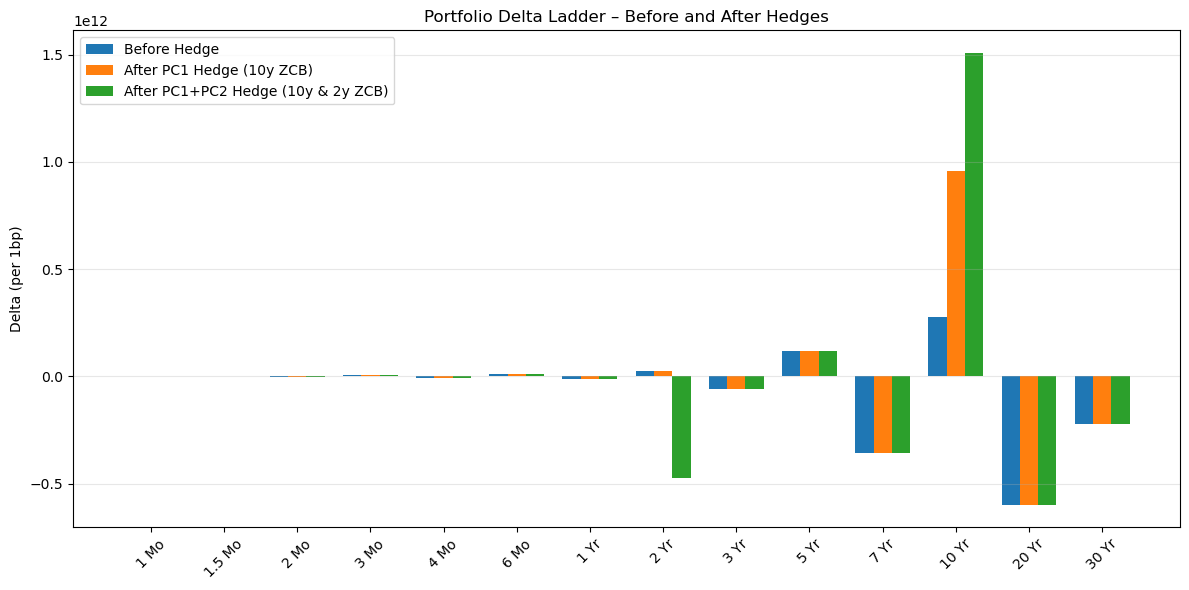

In [70]:
# Graph: portfolio delta ladder before and after hedges

pillar_tenors = np.array([PILLAR_TENORS[c] for c in PILLAR_COLS])

width = 0.25
x = np.arange(len(PILLAR_COLS))

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    portfolio_delta_ladder,
    width=width,
    label="Before Hedge"
)
plt.bar(
    x,
    delta_ladder_after_PC1,
    width=width,
    label="After PC1 Hedge (10y ZCB)"
)
plt.bar(
    x + width,
    delta_ladder_after_PC1_PC2,
    width=width,
    label="After PC1+PC2 Hedge (10y & 2y ZCB)"
)

plt.xticks(x, PILLAR_COLS, rotation=45)
plt.ylabel("Delta (per 1bp)")
plt.title("Portfolio Delta Ladder – Before and After Hedges")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### **8.5 PnL on 10/28/2025 with PC1+PC2 hedge**

In [72]:
pnl_without_hedge_PC12 = portfolio_delta_ladder @ delta_y
pnl_with_PC12_hedge = delta_ladder_after_PC1_PC2 @ delta_y

print("Approx PnL (portfolio only):", pnl_without_hedge_PC12)
print("Approx PnL (with 10y+2y PC1+PC2 hedge):", pnl_with_PC12_hedge)


Approx PnL (portfolio only): 166066034.20428255
Approx PnL (with 10y+2y PC1+PC2 hedge): -29852299.763332278
